<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Worksheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  state_neuron = []
  for i in range(len(X1)):
    current_sum = X1[i] + X2[i]
    if current_sum >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    state_neuron=[]
    for i in range (len(X1)):
      current_sum = X1[i] + X2[i]
      if current_sum >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


• Question - 1: List out all the limitations of MCP - Neurons.

Here are the key limitations of MCP neurons:
1.Lack of Learning Algorithm

2.Binary Inputs and Outputs

3.Limited to Linearly Separable Data

4.Equal Importance to Features

5.Manual Threshold Tuning

6.Lack of Hidden Layers

7.Over-simplification of Biology

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

Yes we can develop a logic to solve for XOR function using MCP Neuron but we can solve it using multiple neurons

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/ConceptAI/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


Question - 1: What does the shape of X represent?

The shape of `X` is `(2741, 784)`. This means:

*   **2741**: Represents the number of samples or instances in the dataset. In this context, it's the total number of handwritten digit images (0s and 1s) that were loaded.
*   **784**: Represents the number of features for each sample. Each image is a 28x28 pixel grayscale image, and when flattened, it results in 28 * 28 = 784 pixel values. So, each row in `X` corresponds to an image, and each column corresponds to a pixel intensity value for that image

Question - 2: What does the shape of X represent?

The shape of `y` is `(2741,)`. This means:

*   **2741**: Represents the total number of labels (outputs) in the dataset, which corresponds directly to the number of samples in `X`. Each label is a single value indicating whether the corresponding image is a '0' or a '1'. The comma after 2741 indicates it's a 1-dimensional array.

### Viewing the Dataset.

(1484, 784)
(1257, 784)


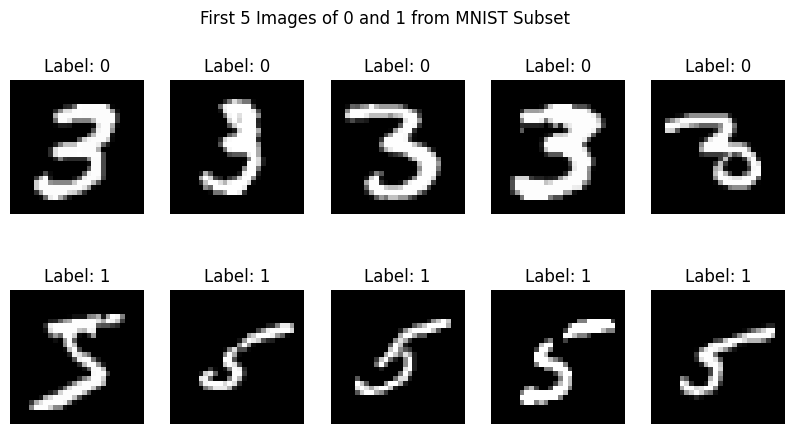

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 3]  # Get all images with label 0
images_1 = X[y == 5]  # Get all images with label 1

print(images_0.shape)
print(images_1.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

**1. Question - 3: What does the weights array represent in this context?**

The weights array, in this perceptron model, represents the learned importance of each input feature (pixel) in classifying an image. Since each image has 784 pixels, there are 784 weights, one for each pixel. During training, these weights are adjusted to determine how much each pixel contributes to the final classification decision.

2. Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

We set weights to zero beacuse it is most straightforward starting point, assuming no prior knowledge of feature importance. Its effect are:


*   Slower Convergence
*   Initial Misclassifications
*   Dependent on First Sample
*   No issue for Linearly Seperable Data
*   Learning Rate Importance


## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    # Step activation function
    y_pred_all = np.where(predictions >= 0, 3, 5)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for i in range(epochs):
        for j in range(len(X)):
            y_pred = decision_function(X[j].reshape(1, -1), weights, bias)[0]
            if y_pred != y[j]:
                update = learning_rate * (y[j] - y_pred)
                weights = weights + update * X[j]
                bias = bias + update

        if i % 10 == 0:
            final_predictions = decision_function(X, weights, bias)
            accuracy = np.mean(final_predictions == y)
            print(f"Epoch {i+10}: Accuracy = {accuracy:.4f}")

    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy

1. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

The line output = np.dot(X[i], weights) + bias calculates the weighted sum of inputs plus the bias for a single training example X[i].

**Purpose**: This output (often called the net input or activation) is then passed to an activation function (in this case, np.where(predictions >= 0, 1, 0) in decision_function) to produce the final binary prediction (0 or 1). It's the core calculation that determines if the neuron fires (outputs 1) or not (outputs 0) based on the combined influence of its inputs and the learned parameters (weights and bias).

2. Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?

When the predection is wrong the perception updates its weight and bais to correct the error.


Calculate the update value: This is determined by learning_rate * (y[j] - y_pred). The term (y[j] - y_pred) is the error signal. If y[j] is 1 (true) and y_pred is 0, the error is +1, meaning the weights and bias need to increase to make the prediction closer to 1. If y[j] is 0 and y_pred is 1, the error is -1, meaning weights and bias need to decrease. The learning_rate controls the step size of this correction.

Update Weights: The weights are adjusted by adding update * X[j] to the current weights. This means that if the perceptron predicted 0 but the true label was 1 (positive error), the weights corresponding to the active input features (X[j]) are increased. If the perceptron predicted 1 but the true label was 0 (negative error), these weights are decreased. This reinforces correct classifications and penalizes incorrect ones.

Update Bias: The bias is adjusted by adding the update value. A positive update increases the bias, making it easier for the perceptron to activate (output 1). A negative update decreases the bias, making it harder to activate.

3. Question - 7:Why is the final accuracy important, and what do you expect it to be?



The final accuracy is important because it serves as a primary metric to evaluate the performance of a classification model. It tells us the proportion of correctly classified instances out of the total instances. A higher accuracy indicates a better-performing model that has successfully learned the patterns in the data.

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.5414
Epoch 20: Accuracy = 0.5414
Epoch 30: Accuracy = 0.5414
Epoch 40: Accuracy = 0.5414
Epoch 50: Accuracy = 0.5414
Epoch 60: Accuracy = 0.5414
Epoch 70: Accuracy = 0.5414
Epoch 80: Accuracy = 0.5414
Epoch 90: Accuracy = 0.5414
Epoch 100: Accuracy = 0.5414
The Final Accuracy is:  0.5414082451659978


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.5414


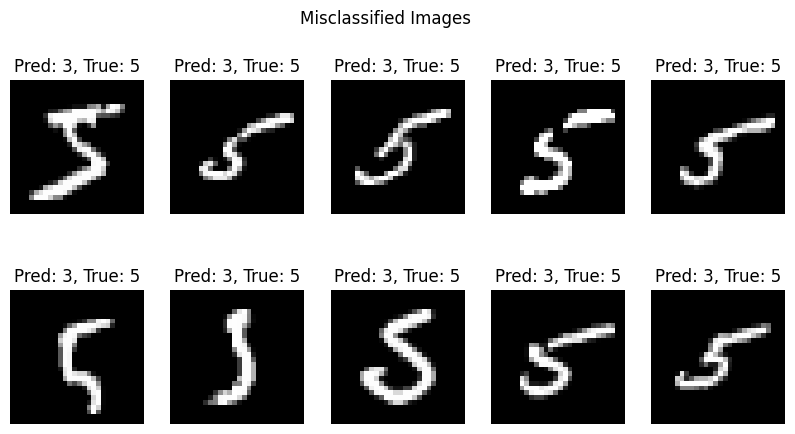

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 3, 5)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")